# EDA: what do the unit-commitment labels look like?

What is tested in this notebook:

1. ON-rate per generator: overall, per case-start year, by hour of day, by month.
2. State "stickiness": hour-to-hour transition rates and all-on / all-off weeks.
3. Price alignment: ON-rate per price decile, per generator.
4. Optimizer difficulty: the solve-time column, by year.
5. AUC ceiling: the per-generator pipeline fit and scored in-sample on 2022.

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
import yaml
from sklearn.metrics import roc_auc_score

HOURS = 168

In [31]:
DATA = "../data/kernel"
EXT = "../data/extended"

price = pd.read_csv(f"{DATA}/Historical_day_ahead_price_2015_2025.csv")
inflow = pd.read_csv(f"{DATA}/Historical_inflow_1958_2025.csv")
volume = pd.read_csv(f"{DATA}/Historical_volume_2015_2024.csv")
water = pd.read_csv(f"{DATA}/Synthetic_water_value_2015_2024.csv")
target = pd.read_csv(f"{DATA}/Unit_commitment_decisions.csv")
min_flow = pd.read_csv(f"{EXT}/Constraint_min_flow.csv")
min_volume = pd.read_csv(f"{EXT}/Constraint_min_volume.csv")
topology = yaml.safe_load(open(f"{EXT}/Tokke_Vinje_topology.yaml"))


def indexed(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], utc=True, format="mixed")
    return df.sort_values("date").set_index("date")


price_h = indexed(price)["Day-ahead price (EUR/MWh)"].resample("1h").mean()
inf_wide = indexed(inflow)
vol_wide = indexed(volume)
wv_wide = indexed(water)
mf_wide = indexed(min_flow)
mv_wide = indexed(min_volume)

RESERVOIRS = list(vol_wide.columns)
CAPACITY = {r: float(topology["model"]["reservoir"][r]["max_vol"]) for r in RESERVOIRS}

target["starttime"] = pd.to_datetime(target["starttime"], utc=True, format="mixed")
target = target.sort_values("starttime").reset_index(drop=True)

GENERATORS = sorted(
    {c.removeprefix("result_committed_").rsplit("_t", 1)[0]
     for c in target.columns if c.startswith("result_committed")}
)

connections = topology["connections"]


def supplying_reservoirs(name, kind):
    if kind == "reservoir":
        return {name}
    out = set()
    for e in connections:
        if e["to"] == name and e["to_type"] == kind and e["from_type"] in {"reservoir", "tunnel"}:
            out |= supplying_reservoirs(e["from"], e["from_type"])
    return out


FEEDERS = {}
for gen in GENERATORS:
    plant = next(e["to"] for e in connections
                 if e["from"] == gen and e["from_type"] == "generator" and e["to_type"] == "plant")
    FEEDERS[gen] = sorted(supplying_reservoirs(plant, "plant"))

LABELS = {
    g: target[[f"result_committed_{g}_t{t}" for t in range(HOURS)]].to_numpy(dtype=np.uint8)
    for g in GENERATORS
}
print("cases:", len(target), " generators:", len(GENERATORS))

cases: 2922  generators: 14


## 1. How much is each unit on?

Tested: overall ON-rate per generator, ON-rate per case-start year,
ON-rate by hour of day, and ON-rate by calendar month (each hour
attributed to the month it actually falls in).


In [32]:
year = target["starttime"].dt.year.to_numpy()
years = sorted(set(year))
rows = []
for g in GENERATORS:
    L = LABELS[g]
    rows.append({"generator": g, "on_rate": L.mean(),
                 **{str(y): L[year == y].mean() for y in years}})
pd.DataFrame(rows).set_index("generator").round(3)

,on_rate,2015,2016,2017,2018,2019,2020,2021,2022
generator,,,,,,,,,
Byrte_G1,0.542,0.437,0.379,0.577,0.573,0.640,0.810,0.537,0.383
Haukeli_G1,0.547,0.874,0.764,0.721,0.781,0.480,0.241,0.371,0.141
Hogga_G1,0.595,0.615,0.562,0.555,0.702,0.590,0.800,0.546,0.387
Kjela_G1,0.471,0.240,0.348,0.702,0.728,0.707,0.445,0.143,0.453
Lio_G1,0.747,0.717,0.615,0.977,0.786,0.970,0.812,0.545,0.550
Songa_G1,0.485,0.299,0.525,0.480,0.658,0.701,0.707,0.397,0.117
Tokke_G1,0.671,0.720,0.755,0.707,0.752,0.581,0.802,0.595,0.457
Tokke_G2,0.478,0.529,0.502,0.456,0.590,0.364,0.592,0.435,0.357
Tokke_G3,0.564,0.618,0.601,0.561,0.666,0.446,0.695,0.516,0.411


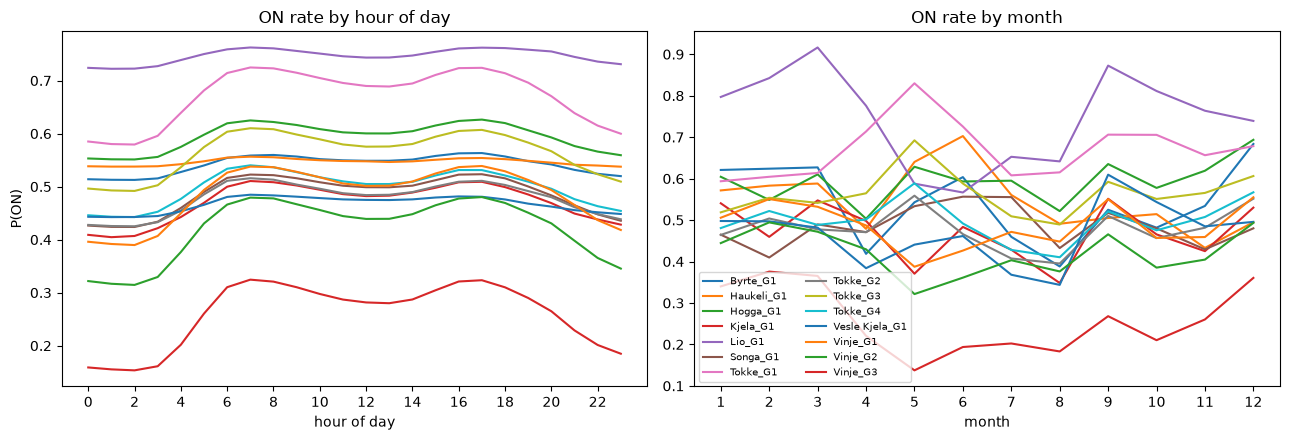

In [33]:
starts = pd.DatetimeIndex(target["starttime"])
ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
    np.tile(np.arange(HOURS), len(starts)), unit="h"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for g in GENERATORS:
    hod = LABELS[g].reshape(-1, 7, 24).mean(axis=(0, 1))
    axes[0].plot(hod, label=g)
axes[0].set(title="ON rate by hour of day", xlabel="hour of day", ylabel="P(ON)")
axes[0].set_xticks(range(0, 24, 2))

month = ts.month.to_numpy()
for g in GENERATORS:
    L = LABELS[g].reshape(-1)
    bym = [L[month == m].mean() for m in range(1, 13)]
    axes[1].plot(range(1, 13), bym, label=g)
axes[1].set(title="ON rate by month", xlabel="month")
axes[1].set_xticks(range(1, 13))
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## 1b. Cyclic patterns across the year

Tested: mean ON-rate per generator by day of year (15-day centered
smoothing) — the annual cycle that motivates the sin/cos day-of-year
encoding. (The within-day cycle is already shown in section 1.)


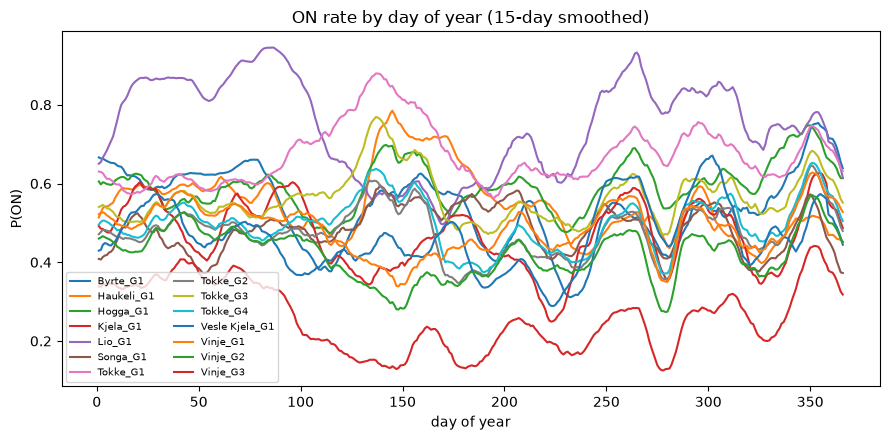

In [34]:
starts = pd.DatetimeIndex(target["starttime"])
ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
    np.tile(np.arange(HOURS), len(starts)), unit="h"
)
doy = ts.dayofyear.to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
for g in GENERATORS:
    L = LABELS[g].reshape(-1)
    grp = pd.DataFrame({"doy": doy, "on": L}).groupby("doy")["on"].mean()
    grp = grp.reindex(range(1, 367)).interpolate(limit_direction="both")
    smooth = grp.rolling(15, center=True, min_periods=1).mean()
    ax.plot(smooth.index, smooth.to_numpy(), label=g)
ax.set(title="ON rate by day of year (15-day smoothed)",
       xlabel="day of year", ylabel="P(ON)")
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## 2. How sticky is the on/off state?

Tested: P(on|on) and P(off|off) for hour-to-hour transitions within
case-weeks, the hourly flip rate, and the fraction of case-weeks that are
fully on or fully off.

In [35]:
rows = []
for g in GENERATORS:
    L = LABELS[g].astype(bool)
    stay_on = L[:, 1:][L[:, :-1]].mean()
    stay_off = (~L[:, 1:])[~L[:, :-1]].mean()
    flips = (L[:, 1:] != L[:, :-1]).mean()
    week_mean = L.mean(axis=1)
    rows.append({"generator": g,
                 "P(on|on)": stay_on, "P(off|off)": stay_off,
                 "flip_rate": flips,
                 "weeks_all_on": (week_mean == 1).mean(),
                 "weeks_all_off": (week_mean == 0).mean()})
pd.DataFrame(rows).set_index("generator").round(3)

,P(on|on),P(off|off),flip_rate,weeks_all_on,weeks_all_off
generator,,,,,
Byrte_G1,0.995,0.993,0.006,0.415,0.323
Haukeli_G1,0.997,0.997,0.003,0.488,0.325
Hogga_G1,0.991,0.987,0.010,0.387,0.183
Kjela_G1,0.986,0.986,0.014,0.259,0.287
Lio_G1,0.995,0.986,0.007,0.576,0.123
Songa_G1,0.988,0.988,0.012,0.294,0.299
Tokke_G1,0.987,0.972,0.018,0.398,0.089
Tokke_G2,0.988,0.989,0.012,0.306,0.286
Tokke_G3,0.987,0.982,0.015,0.351,0.187


## 3. Does price line up with commitment?

Tested: ON-rate per price decile (deciles computed over all case-hours
2015-2022), per generator.

In [36]:
starts = pd.DatetimeIndex(target["starttime"])
n = len(starts)
ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
    np.tile(np.arange(HOURS), n), unit="h"
)
P = price_h.reindex(ts).to_numpy(dtype=np.float32).reshape(n, HOURS)

edges = np.quantile(P, np.linspace(0, 1, 11))
bin_idx = np.clip(np.digitize(P, edges[1:-1]), 0, 9)

rows = []
for g in GENERATORS:
    L = LABELS[g]
    rows.append({"generator": g,
                 **{f"q{b + 1}": L[bin_idx == b].mean() for b in range(10)}})
pd.DataFrame(rows).set_index("generator").round(3)

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10
generator,,,,,,,,,,
Byrte_G1,0.722,0.740,0.450,0.469,0.479,0.510,0.591,0.661,0.432,0.366
Haukeli_G1,0.352,0.664,0.766,0.758,0.615,0.546,0.628,0.653,0.329,0.159
Hogga_G1,0.671,0.691,0.602,0.635,0.579,0.669,0.586,0.621,0.454,0.438
Kjela_G1,0.234,0.477,0.403,0.410,0.581,0.528,0.655,0.655,0.338,0.424
Lio_G1,0.764,0.793,0.673,0.810,0.862,0.820,0.893,0.751,0.479,0.618
Songa_G1,0.515,0.549,0.644,0.528,0.388,0.461,0.739,0.690,0.214,0.124
Tokke_G1,0.718,0.802,0.761,0.754,0.671,0.679,0.624,0.669,0.519,0.511
Tokke_G2,0.505,0.662,0.489,0.494,0.453,0.451,0.461,0.509,0.350,0.409
Tokke_G3,0.611,0.725,0.605,0.601,0.542,0.556,0.520,0.579,0.438,0.466


## 4. How hard was each case for the optimizer?

Tested: the distribution of `total_calculation_time` and its per-year mean
and max. The column exists for train cases only, not for the test set.

In [37]:
t = target["total_calculation_time"]
print(t.describe().round(1))
print()
print(target.groupby(target["starttime"].dt.year)["total_calculation_time"].agg(["mean", "max"]).round(1))

count    2922.0
mean      147.0
std       333.1
min        22.4
25%        40.0
50%        51.7
75%        78.3
max      4525.7
Name: total_calculation_time, dtype: float64

            mean     max
starttime               
2015       169.2  4525.7
2016       181.9  1939.0
2017       150.1  2364.6
2018       145.4  2252.3
2019       191.3  2843.5
2020       114.2  3247.0
2021        86.6  1279.3
2022       137.3  3678.4


## 5. What is the AUC ceiling?

Tested: the exact per-generator pipeline (same features, same
hyperparameters, no early stopping) fit on the 2022 cases and scored on
those same cases. This measures how well the features can express the labels
in-sample, not generalization.

In [38]:
def lookup(frame, timestamps, columns=None):
    f = frame if columns is None else frame[columns]
    return f.reindex(pd.DatetimeIndex(timestamps)).to_numpy(dtype=np.float32)


def feature_matrix(cases):
    starts = pd.DatetimeIndex(cases["starttime"])
    n = len(starts)
    ts = pd.DatetimeIndex(np.repeat(starts.to_numpy(), HOURS)) + pd.to_timedelta(
        np.tile(np.arange(HOURS), n), unit="h"
    )
    price = lookup(price_h, ts).reshape(n, HOURS)
    initial = lookup(vol_wide, starts, RESERVOIRS)
    terminal = lookup(wv_wide, starts + pd.Timedelta(hours=HOURS), RESERVOIRS)
    inflow = lookup(inf_wide, ts).reshape(n, HOURS, -1)
    minflow = lookup(mf_wide, ts).reshape(n, HOURS, -1)
    minvol = lookup(mv_wide, ts).reshape(n, HOURS, -1)

    F = {}

    def add(name, v):
        v = np.asarray(v, dtype=np.float32)
        if v.shape == (n,):
            v = np.repeat(v, HOURS)
        elif v.shape == (n, HOURS):
            v = v.reshape(-1)
        F[name] = v

    h = np.tile(np.arange(HOURS, dtype=np.float32), n)
    add("horizon_hour", h)
    add("hours_remaining", HOURS - 1 - h)
    add("hour_of_day", ts.hour.to_numpy())
    add("day_of_week", ts.dayofweek.to_numpy())
    add("month", ts.month.to_numpy())
    add("doy_sin", np.sin(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))
    add("doy_cos", np.cos(2 * np.pi * ts.dayofyear.to_numpy() / 365.25))

    add("price", price)
    for stat, v in (("mean", price.mean(1)), ("std", price.std(1)),
                    ("min", price.min(1)), ("max", price.max(1))):
        add(f"price_week_{stat}", v)
    add("price_minus_week_mean", price - price.mean(1, keepdims=True))
    add("price_week_rank", pd.DataFrame(price).rank(axis=1, pct=True).to_numpy())
    daily = price.reshape(n, 7, 24)
    for stat, v in (("mean", daily.mean(2)), ("min", daily.min(2)), ("max", daily.max(2))):
        add(f"price_day_{stat}", np.repeat(v, 24, axis=1))
    add("price_prefix_mean", price.cumsum(1) / np.arange(1, HOURS + 1))
    add("price_suffix_mean", price[:, ::-1].cumsum(1)[:, ::-1] / np.arange(HOURS, 0, -1))
    for off in (-24, -6, -1, 1, 6, 24):
        add(f"price_offset_{off:+d}", price[:, np.clip(np.arange(HOURS) + off, 0, HOURS - 1)])

    for j, res in enumerate(RESERVOIRS):
        add(f"init_vol__{res}", initial[:, j])
        add(f"init_frac__{res}", initial[:, j] / CAPACITY[res])
        add(f"term_val__{res}", terminal[:, j])
        add(f"price_minus_val__{res}", price - terminal[:, j, None])

    for j, name in enumerate(inf_wide.columns):
        flow = inflow[:, :, j]
        cum = flow.cumsum(1) * (3600 / 1e6)
        add(f"inflow__{name}", flow)
        add(f"inflow_week_mean__{name}", flow.mean(1))
        add(f"inflow_cum_Mm3__{name}", cum)
        add(f"inflow_rem_Mm3__{name}", cum[:, -1:] - cum)

    for j, name in enumerate(mf_wide.columns):
        add(f"minflow__{name}", minflow[:, :, j])
        add(f"minflow_week_max__{name}", minflow[:, :, j].max(1))
    for j, name in enumerate(mv_wide.columns):
        add(f"minvol__{name}", minvol[:, :, j])
        add(f"minvol_week_max__{name}", minvol[:, :, j].max(1))
        add(f"init_margin_to_minvol__{name}", initial[:, RESERVOIRS.index(name), None] - minvol[:, :, j])

    return pd.DataFrame(F, dtype=np.float32)


def generator_features(base, gen):
    X = base.copy()
    feeders = FEEDERS[gen]
    capacity = sum(CAPACITY[r] for r in feeders)
    total_init = sum(base[f"init_vol__{r}"] for r in feeders)
    value = sum(base[f"term_val__{r}"] * CAPACITY[r] for r in feeders) / capacity
    cum = sum(base[f"inflow_cum_Mm3__{r}"] for r in feeders)
    rem = sum(base[f"inflow_rem_Mm3__{r}"] for r in feeders)

    X["local_init_frac"] = total_init / capacity
    X["local_term_val"] = value
    X["local_price_minus_val"] = base["price"] - value
    X["local_inflow"] = sum(base[f"inflow__{r}"] for r in feeders)
    X["local_cum_frac"] = cum / capacity
    X["local_rem_frac"] = rem / capacity
    X["local_available_frac"] = (total_init + cum + rem) / capacity
    return X


def labels_for(cases, gen):
    cols = [f"result_committed_{gen}_t{t}" for t in range(HOURS)]
    return cases[cols].to_numpy(dtype=np.uint8).reshape(-1)

In [39]:
val = target[target["starttime"].dt.year == 2022].reset_index(drop=True)
Xva_base = feature_matrix(val)
print("2022 cases:", len(val), " feature matrix:", Xva_base.shape)

insample_preds, rows = {}, []
for gen in GENERATORS:
    X = generator_features(Xva_base, gen)
    y = labels_for(val, gen)
    if np.unique(y).size == 1:
        insample_preds[gen] = np.full(len(y), float(y[0]), dtype=np.float32)
        rows.append({"generator": gen, "AUC": None})
        continue
    clf = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, tree_method="hist",
        eval_metric="auc", random_state=0,
    )
    clf.fit(X, y)
    p = clf.predict_proba(X)[:, 1].astype(np.float32)
    insample_preds[gen] = p
    rows.append({"generator": gen, "AUC": roc_auc_score(y, p)})
    print(f"{gen:16s} in-sample AUC {rows[-1]['AUC']:.4f}")

y_all = np.concatenate([labels_for(val, g) for g in GENERATORS])
p_all = np.concatenate([insample_preds[g] for g in GENERATORS])
print("in-sample micro AUC (2022):", round(roc_auc_score(y_all, p_all), 4))
pd.DataFrame(rows).set_index("generator").round(4)

2022 cases: 365  feature matrix: (61320, 186)
Byrte_G1         in-sample AUC 1.0000
Haukeli_G1       in-sample AUC 1.0000
Hogga_G1         in-sample AUC 1.0000
Kjela_G1         in-sample AUC 1.0000
Lio_G1           in-sample AUC 1.0000
Songa_G1         in-sample AUC 1.0000
Tokke_G1         in-sample AUC 1.0000
Tokke_G2         in-sample AUC 1.0000
Tokke_G3         in-sample AUC 1.0000
Tokke_G4         in-sample AUC 1.0000
Vesle Kjela_G1   in-sample AUC 1.0000
Vinje_G1         in-sample AUC 1.0000
Vinje_G2         in-sample AUC 1.0000
Vinje_G3         in-sample AUC 0.9999
in-sample micro AUC (2022): 1.0


,AUC
generator,
Byrte_G1,1.0000
Haukeli_G1,1.0000
Hogga_G1,1.0000
Kjela_G1,1.0000
Lio_G1,1.0000
Songa_G1,1.0000
Tokke_G1,1.0000
Tokke_G2,1.0000
Tokke_G3,1.0000
